# Text Preprocessing

Processing the text of the airlines dataframe to remove mentions, hashtags, emojis, acronyms etc. to ensure the data is ready for tokenization step

## Importing Packages

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import emoji
import contractions

sns.set_theme(style='ticks')


## Load Dataset

In [3]:
airlines = pd.read_csv(r'C:\Users\karina mehta\UVA class\Semester 2\Text As Data\us_airlines_dataset\Tweets.csv')
airlines.head(1)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)


In [4]:
airline_table = airlines[['airline','retweet_count','text','tweet_created','tweet_location','user_timezone']].copy()

In [5]:
airline_table.head(1)

,airline,retweet_count,text,tweet_created,tweet_location,user_timezone
0,Virgin America,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)


## Handling Datatype

In [6]:
airline_table.dtypes
airline_table['tweet_created'] = pd.to_datetime(airline_table['tweet_created'], utc=True)
airline_table.dtypes

airline                        object
retweet_count                   int64
text                           object
tweet_created     datetime64[ns, UTC]
tweet_location                 object
user_timezone                  object
dtype: object

In [7]:
#Creating Day and Time columns
airline_table['day'] = airline_table['tweet_created'].dt.day
airline_table['hour'] = airline_table['tweet_created'].dt.hour
airline_table['day_of_week'] = airline_table['tweet_created'].dt.dayofweek
airline_table['day_name'] = airline_table['tweet_created'].dt.day_name()
airline_table.head()

,airline,retweet_count,text,tweet_created,tweet_location,user_timezone,day,hour,day_of_week,day_name
0,Virgin America,0,@VirginAmerica What @dhepburn said.,2015-02-24 19:35:52+00:00,NaN,Eastern Time (US & Canada),24,19,1,Tuesday
1,Virgin America,0,@VirginAmerica plus you've added commercials t...,2015-02-24 19:15:59+00:00,NaN,Pacific Time (US & Canada),24,19,1,Tuesday
2,Virgin America,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 19:15:48+00:00,Lets Play,Central Time (US & Canada),24,19,1,Tuesday
3,Virgin America,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 19:15:36+00:00,NaN,Pacific Time (US & Canada),24,19,1,Tuesday
4,Virgin America,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 19:14:45+00:00,NaN,Pacific Time (US & Canada),24,19,1,Tuesday


## Removing Mentions, URLS and hashtags from text

In [ ]:
# Load slang dict with original-case keys; skip multi-word expansions to avoid noise
# (e.g. "IT" → "information technology" would split into two high-frequency tokens)
_df_slang  = pd.read_csv('slang/slang.txt', sep='\t', names=['acronym', 'expansion'])
_chat_words = {
    k: v.lower()
    for k, v in _df_slang.set_index('acronym')['expansion'].to_dict().items()
    if ' ' not in v                          # skip multi-word expansions
}

def _chat_conversion(text):
    # Case-sensitive: 'LOL' matches dict key, 'lol' (after lowercasing) does not
    return ' '.join(_chat_words.get(w, w) for w in text.split())

def extract_and_clean(text):
    mentions = re.findall(r'@\w+', text)
    hashtags = re.findall(r'#\w+', text)

    text = re.sub(r'@\w+', '', text)                   # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'#(\w+)', r'\1', text)               # remove # keep word
    text = re.sub(r'&amp;', '&', text)                  # fix HTML entities
    text = re.sub(r'<.*?>', '', text)                   # remove HTML tags
    text = re.sub(r'\s+', ' ', text)                    # collapse whitespace
    text = contractions.fix(text)                       # expand contractions
    text = emoji.demojize(text)                         # convert emojis to :name:
    text = _chat_conversion(text)                       # slang expansion (before lower)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)         # normalize elongation
    text = text.strip().lower()

    return {
        'cleaned_text': text,
        'mentions'    : mentions if mentions else None,
        'hashtags'    : hashtags if hashtags else None,
    }

In [9]:
extracted = airline_table['text'].apply(extract_and_clean)
airline_table['cleaned_text'] = extracted.apply(lambda x: x['cleaned_text'])
airline_table['mentions']     = extracted.apply(lambda x: x['mentions'])
airline_table['hashtags']     = extracted.apply(lambda x: x['hashtags'])

## Expansion

#### Chat Words
Expanding acronyms into full length words

In [ ]:
# Slang dictionary is now loaded inside extract_and_clean above

In [ ]:
# chat_words and chat_conversion are handled inside extract_and_clean

In [ ]:
# chat_conversion is handled inside extract_and_clean

In [ ]:
# chat_conversion is applied inside extract_and_clean — no separate step needed

In [14]:
airline_table['text'][3]

'@VirginAmerica it\'s really aggressive to blast obnoxious "entertainment" in your guests\' faces &amp; they have little recourse'

In [15]:
airline_clean = airline_table[['airline','mentions','hashtags','tweet_created','day','hour','day_of_week','day_name','retweet_count','cleaned_text']].copy()
airline_clean.head()

,airline,mentions,hashtags,tweet_created,day,hour,day_of_week,day_name,retweet_count,cleaned_text
0,Virgin America,"[@VirginAmerica, @dhepburn]",None,2015-02-24 19:35:52+00:00,24,19,1,Tuesday,0,what said.
1,Virgin America,[@VirginAmerica],None,2015-02-24 19:15:59+00:00,24,19,1,Tuesday,0,plus you have added commercials to the experie...
2,Virgin America,[@VirginAmerica],None,2015-02-24 19:15:48+00:00,24,19,1,Tuesday,0,i did not today.. must mean i need to take ano...
3,Virgin America,[@VirginAmerica],None,2015-02-24 19:15:36+00:00,24,19,1,Tuesday,0,"it is really aggressive to blast obnoxious ""en..."
4,Virgin America,[@VirginAmerica],None,2015-02-24 19:14:45+00:00,24,19,1,Tuesday,0,and it is a really big bad thing about it


#### Extracting Features

In [16]:
airline_clean['str_len'] = airline_clean.cleaned_text.str.len()
airline_clean.str_len.describe()

count    14640.000000
mean        90.541325
std         37.399066
min          1.000000
25%         62.000000
50%         99.000000
75%        123.000000
max        602.000000
Name: str_len, dtype: float64

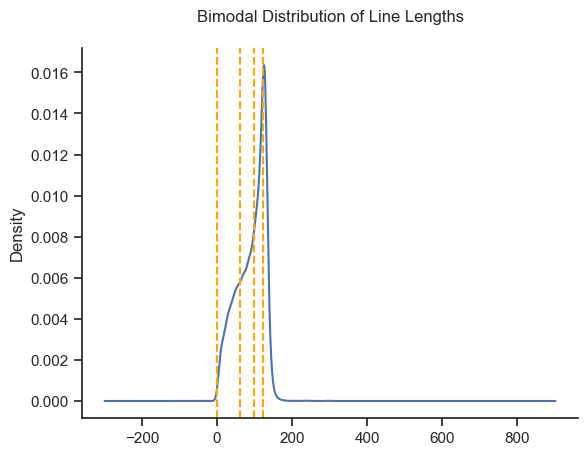

In [17]:
ax = airline_clean['str_len'].plot.kde()
ax.axvline(1, c='orange', ls='--')
ax.axvline(61, c='orange', ls='--')
ax.axvline(98, c='orange', ls='--')
ax.axvline(122, c='orange', ls='--')
plt.title("Bimodal Distribution of Line Lengths", y=1.05)
sns.despine()
plt.show()

#### Saving Clean Dataset

In [18]:
airline_clean.head()

,airline,mentions,hashtags,tweet_created,day,hour,day_of_week,day_name,retweet_count,cleaned_text,str_len
0,Virgin America,"[@VirginAmerica, @dhepburn]",None,2015-02-24 19:35:52+00:00,24,19,1,Tuesday,0,what said.,10
1,Virgin America,[@VirginAmerica],None,2015-02-24 19:15:59+00:00,24,19,1,Tuesday,0,plus you have added commercials to the experie...,58
2,Virgin America,[@VirginAmerica],None,2015-02-24 19:15:48+00:00,24,19,1,Tuesday,0,i did not today.. must mean i need to take ano...,56
3,Virgin America,[@VirginAmerica],None,2015-02-24 19:15:36+00:00,24,19,1,Tuesday,0,"it is really aggressive to blast obnoxious ""en...",108
4,Virgin America,[@VirginAmerica],None,2015-02-24 19:14:45+00:00,24,19,1,Tuesday,0,and it is a really big bad thing about it,41


In [ ]:
airline_clean.to_parquet('airline_clean.parquet', engine='pyarrow', index=False)